# Plot the outcomes of single site extracted from the regional run

In [86]:
import os
import xarray as xr
from glob import glob
import pandas as pd
import numpy as np
from shared_read_HBR import *
from matplotlib import rcParams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import itertools as it

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

# soil layer depths in ELM
zsoi = np.array([0.0071, 0.0279, 0.0623, 0.1189, 0.2122, 0.3661, 0.6198, 1.0380, 1.7276, 2.8646])
zisoi = np.array([0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 1.3828, 2.2961, 3.8019])
dzsoi = np.array([0.0175, 0.0276, 0.0455, 0.0750, 0.1236, 0.2038, 0.3360, 0.5539, 0.9133, 1.5058])

# major cation list
cations = ['Ca2+','Mg2+','Na+','K+','Al3+']

# list of NetCDF file names generated by ELM
date_prefix = '20250427'
region = 'conus'
start = 1980 # pre-1920 met forcing are not reliable; just focus on more recent periods
end = 2010
case_suffix = 'ICB20TRCNPRDCTCBC_3yearerw'

if '1850CN' in case_suffix:
    tvec = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1D')
    tvec_mon = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1MS')
    tvec_yr = pd.date_range(f'{start+2000}-01-01', f'{end+2000}-12-31', freq = '1YS')
else:
    tvec = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1D')
    tvec_mon = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1MS')
    tvec_yr = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1YS')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
case_name = f'{date_prefix}_{region}_{case_suffix}'
file_list = [os.path.join(os.environ['E3SM_ROOT'], 'output', case_name, 'run', 
                          f'{case_name}.elm.h1.{year:04d}-01-01-00000.nc') \
             for year in range(start, end + 1)]

# path to save the graphs
path_out = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'plot_ERWsites', case_name)
if not os.path.exists(path_out):
    os.mkdir(os.path.join(path_out))

In [88]:
site_list = pd.DataFrame(
    {'lat': [40.75, 39.75, 38.39],
     'lon': [282.25, 282.25, 238.59]}, 
    index = ['site_1', 'site_2', 'site_3']
)

hr = xr.open_mfdataset(file_list)

In [ ]:
# Plot the mineral addition sequence from input file
inputdata = pd.DataFrame(np.nan, columns = site_list.index, index = range(1850, 2101))
hr_surf = xr.open_dataset(os.path.join(
    os.environ['E3SM_ROOT'], 'inputdata', 'lnd', 'clm2', 'surfdata_map', 
    'erw_ensemble_JRA55', 'landuse.conus_erw_on_combined_simyr1850-2100_c240508_ensemble_1.nc'))
for site, (lat,lon) in site_list.iterrows():
    row,col = np.where((hr_surf['LONGXY'] == lon) & (hr_surf['LATIXY'] == lat))
    row = row[0]
    col = col[0]
    # kg/m2/yr-1, convert to forsterite fraction
    pft = 0; min = 1
    inputdata.loc[:, site] = hr_surf['SOIL_AMENDMENTS_RATE'][:, pft, row, col].values * \
                             hr_surf['SOIL_AMENDMENTS_PCT'][:, min, row, col] / 100
hr_surf.close()

Text(0, 0.5, 'Added forsterite (kg m-2 yr-1)')

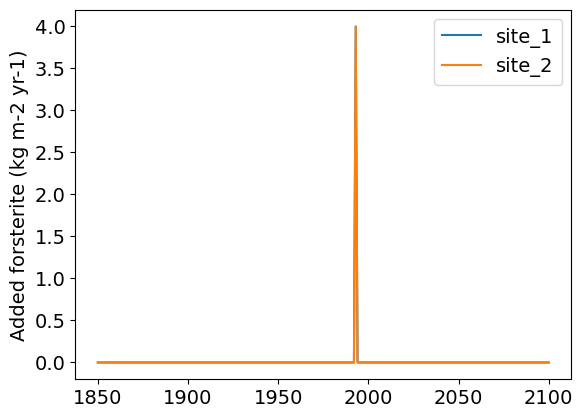

In [ ]:
inputdata.plot()
plt.ylabel('Added forsterite (kg m-2 yr-1)')

# 1. Mineral dissolution balance

Primary mineral added

Primary mineral dissolved

In [89]:
primary_mineral = pd.DataFrame(np.nan, columns = site_list.index, index = tvec)
primary_added = pd.DataFrame(np.nan, columns = site_list.index, index = tvec)
primary_dissolve =pd.DataFrame(np.nan, columns = site_list.index, index = tvec)
for site, (lat,lon) in site_list.iterrows():
    primary_mineral[site] = hr['primary_mineral'].sel(lat=lat, lon=lon, method='nearest')[:, 1]
    primary_added[site] = hr['primary_added'].sel(lat=lat, lon=lon, method='nearest')[:, 1]
    primary_dissolve[site] = hr['primary_dissolve'].sel(lat=lat, lon=lon, method='nearest')[:, 1]
# unite conversion
# g m-2 s-1 => kg m-2 day-1, to faciliate summation
primary_added = primary_added * 86400 / 1000
primary_dissolve = primary_dissolve * 86400 / 1000

<Axes: >

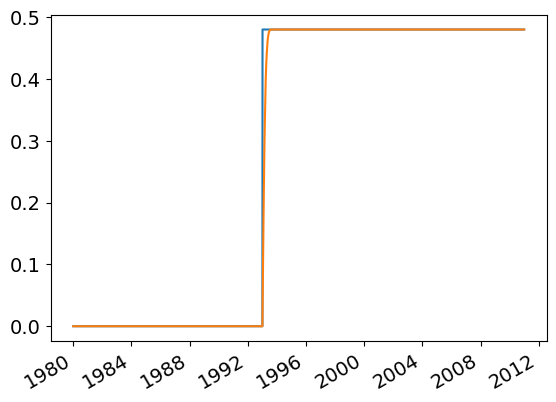

In [90]:
site = 'site_3'
#primary_mineral[site].plot()
primary_added[site].cumsum().plot()
primary_dissolve[site].cumsum().plot()

# 2. Pore water cation balance

 background weathering influx
 
 primary cation flux
 
 CEC cation flux
 
 secondary cation flux
 
 cation_infl_vr
 
 cation_leached_vr
 
 cation_runoff_vr

 change in cation storage

 check each layer

In [ ]:
site = 'site_3'
lat = site_list.loc[site, 'lat']
lon = site_list.loc[site, 'lon']
layer = 8 # tested 3 and 8

background = hr['background_flux_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values
primary = hr['primary_cation_flux_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values
cec = hr['cec_cation_flux_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values + \
      hr['cec_cation_flux2_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values
secondary = hr['secondary_cation_flux_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values
infl = hr['cation_infl_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values
leach = hr['cation_leached_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values

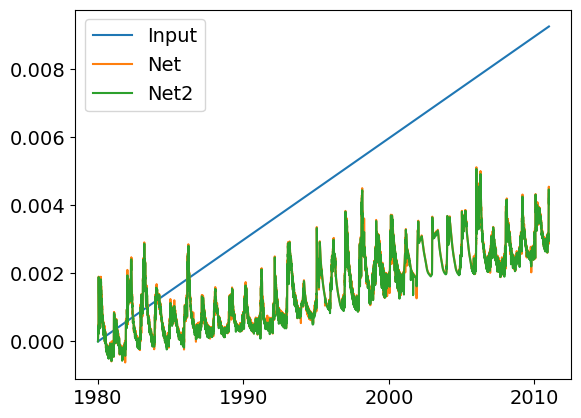

In [114]:
# Check if net input & output approximately equals change in storage
# Yes
plt.plot(hr['time'],
         (background + primary).cumsum() * 86400, label = 'Input')
plt.plot(hr['time'],
         (background + primary + cec - secondary + infl - leach).cumsum() * 86400,
         label = 'Net')
plt.plot(hr['time'], 
         hr['cation_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values - 
         hr['cation_vr_2'].sel(lat=lat,lon=lon,method='nearest')[:,layer].values[0],
         label = 'Net2')
plt.legend()

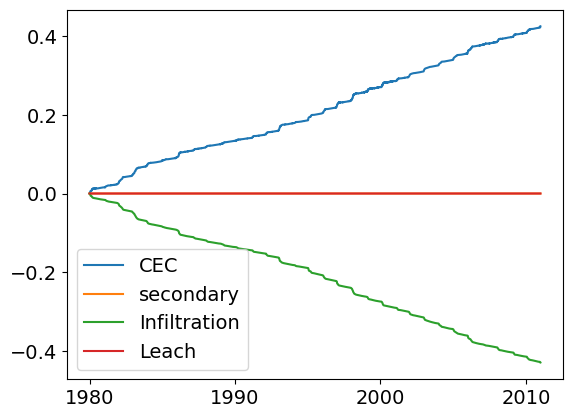

In [112]:
# Plot the individual terms
plt.plot(hr['time'], cec.cumsum()*86400, label = 'CEC')
plt.plot(hr['time'], -secondary.cumsum()*86400, label = 'secondary')
plt.plot(hr['time'], infl.cumsum()*86400, label = 'Infiltration')
plt.plot(hr['time'], -leach.cumsum()*86400, label = 'Leach')
plt.legend()